# MRC Psycholinguistic Database Exploration

This notebook loads the cleaned MRC psycholinguistic database used in your thesis and visualises relationships between key variables:

- Age of Acquisition (`aoa`)
- Concreteness (`conc`)
- Imageability (`img`)
- Familiarity (`fam`)
- Kucera–Francis written frequency (`kf_freq`)


In [ ]:
from __future__ import annotations

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from setup_mrc_database import setup_mrc_database

sns.set_theme(context="notebook", style="whitegrid")
%matplotlib inline

In [ ]:
# Load cleaned MRC dataframe
mrc_df = setup_mrc_database()
mrc_df.head()
print("aoa" in mrc_df.columns)
print([c for c in mrc_df.columns if "acquisition" in c.lower() or c == "aoa"])

--- Loading MRC psycholinguistic database ---
Success! Final columns for analysis: ['word', 'nlet', 'number of phonemes', 'number of syllables', 'kf_freq', 'kf number of categories', 'kf number of samples', 'thorndike-lorge frequency', 'brown verbal frequency', 'fam']...
Filtered to 9335 words with psycholinguistic ratings.


,word,nlet,number of phonemes,number of syllables,kf_freq,kf number of categories,kf number of samples,thorndike-lorge frequency,brown verbal frequency,fam,...,comprehensive syntactic category,common part of speech,morphemic status,contextual status,pronunciation variability,capitalization,irregular plural,stress-marked phonetic transcription,syllabified phonetic transcription,stress pattern
326,A,1,1,1,23237.0,15,500,117222,5006,632.0,...,N,,,,B,,Y,NaN,eI,NaN
327,A,1,1,1,23237.0,15,500,117222,5006,632.0,...,O,O,,,B,,,eI,@,0.0
466,ABANDON,7,0,3,17.0,8,15,150,1,510.0,...,A,,,O,,,,NaN,NaN,NaN
467,ABANDON,7,7,3,17.0,8,15,150,1,510.0,...,N,N,,O,,,N,@/b&n/d@n,@'b&nd@n,20.0
468,ABANDON,7,7,3,17.0,8,15,150,1,510.0,...,V,V,,S,,,,@/b&n/d@n,@'b&nd@n,20.0


In [ ]:
# Dataset size / coverage ("how much data do I have?")

print(f"Rows (word entries): {len(mrc_df):,}")
print(f"Columns: {mrc_df.shape[1]:,}")

if "word" in mrc_df.columns:
    print(f"Unique word forms: {mrc_df['word'].nunique(dropna=True):,}")

vars_of_interest = [c for c in ["fam", "conc", "img", "aoa", "kf_freq", "nlet"] if c in mrc_df.columns]

coverage = (
    mrc_df[vars_of_interest]
    .isna()
    .mean()
    .mul(100)
    .rename("pct_missing")
    .to_frame()
)
coverage["pct_present"] = 100 - coverage["pct_missing"]
coverage["n_missing"] = mrc_df[vars_of_interest].isna().sum()
coverage["n_present"] = mrc_df[vars_of_interest].notna().sum()

coverage.sort_values("pct_missing")

Rows (word entries): 9,335
Columns: 26
Unique word forms: 4,890


,pct_missing,pct_present,n_missing,n_present
fam,0.000000,100.000000,0,9335
nlet,0.000000,100.000000,0,9335
img,1.606856,98.393144,150,9185
kf_freq,9.662560,90.337440,902,8433
conc,12.372791,87.627209,1155,8180
aoa,62.656668,37.343332,5849,3486


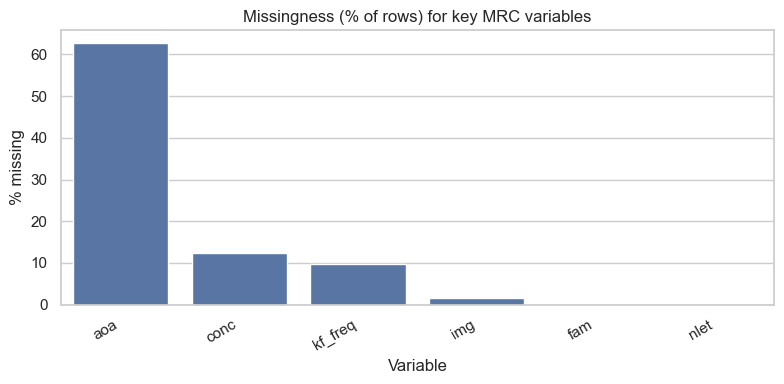

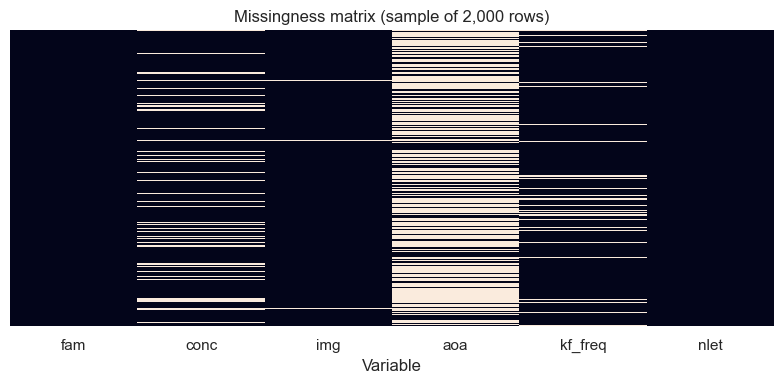

In [ ]:
# Missingness visualisations

# 1) Bar chart: % missing for key variables
if vars_of_interest:
    miss_pct = mrc_df[vars_of_interest].isna().mean().mul(100).sort_values(ascending=False)

    plt.figure(figsize=(8, 4))
    ax = sns.barplot(x=miss_pct.index, y=miss_pct.values)
    ax.set_ylabel("% missing")
    ax.set_xlabel("Variable")
    ax.set_title("Missingness (% of rows) for key MRC variables")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

# 2) Missingness matrix sample (helps you see patterns)
# Showing all rows can be too heavy, so we sample.
missing_cols = vars_of_interest
sample_n = min(2000, len(mrc_df))

plt.figure(figsize=(8, 4))
sns.heatmap(
    mrc_df[missing_cols].sample(sample_n, random_state=42).isna(),
    cbar=False,
    yticklabels=False,
)
plt.title(f"Missingness matrix (sample of {sample_n:,} rows)")
plt.xlabel("Variable")
plt.tight_layout()

In [ ]:
# Basic overview
mrc_df.describe(include="all")

,word,nlet,number of phonemes,number of syllables,kf_freq,kf number of categories,kf number of samples,thorndike-lorge frequency,brown verbal frequency,fam,...,comprehensive syntactic category,common part of speech,morphemic status,contextual status,pronunciation variability,capitalization,irregular plural,stress-marked phonetic transcription,syllabified phonetic transcription,stress pattern
count,9335,9335.000000,9335.000000,9335.000000,8433.000000,9335.000000,9335.000000,9335.000000,9335.000000,9335.000000,...,9335,9335,9335,9335,9335,9335,9335,6370,7310,6370.000000
unique,4890,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11,5,3,11,3,2,6,4431,4829,NaN
top,BUT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,N,N,,S,,,,tu,fO2,NaN
freq,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4325,3701,9330,7681,9070,9142,8720,7,8,NaN
mean,NaN,5.913551,3.412319,1.828174,239.947943,7.158222,46.206213,1069.412426,44.553401,488.260739,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,193.784301
std,NaN,2.127831,2.888433,0.926504,1875.749219,5.171634,91.703649,7100.114270,295.422604,98.791764,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2039.662650
min,NaN,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,43.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
25%,NaN,4.000000,0.000000,1.000000,5.000000,2.000000,3.000000,22.000000,0.000000,443.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000
50%,NaN,5.000000,3.000000,2.000000,20.000000,7.000000,11.000000,103.000000,1.000000,510.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000
75%,NaN,7.000000,5.000000,2.000000,70.000000,12.000000,40.000000,387.500000,6.000000,557.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000


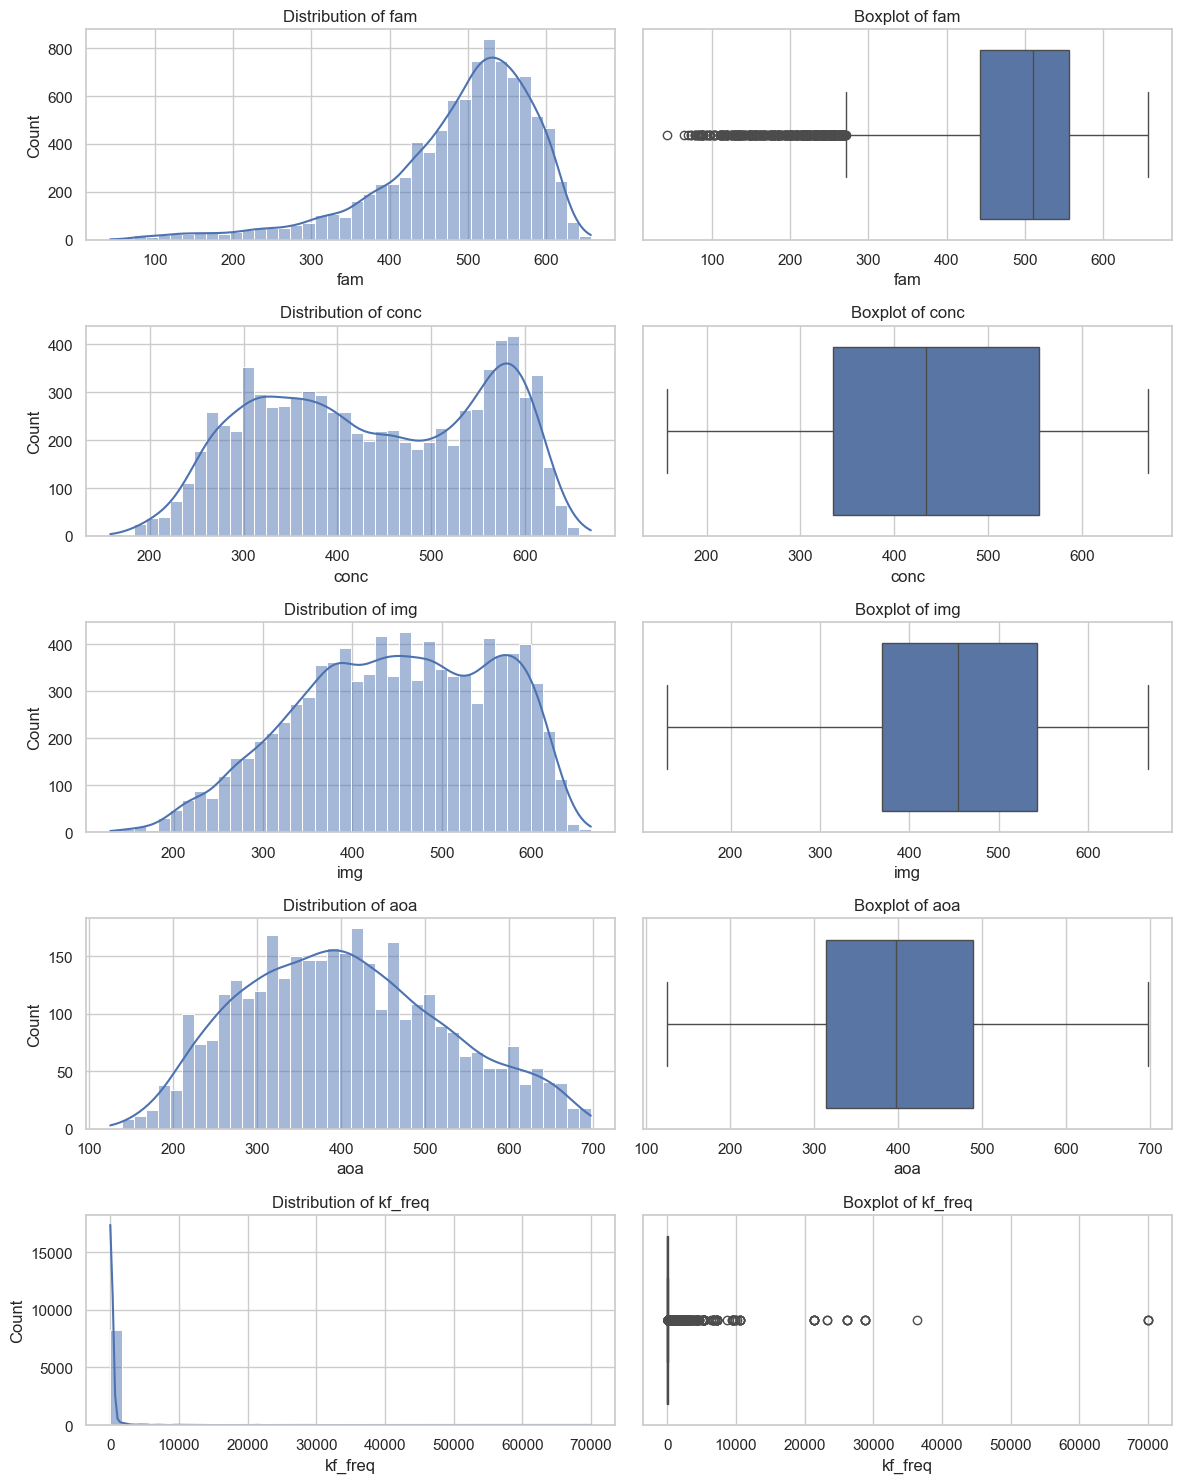

In [ ]:
# Distributions of key psycholinguistic variables
vars_of_interest = ["fam", "conc", "img", "aoa", "kf_freq"]

fig, axes = plt.subplots(len(vars_of_interest), 2, figsize=(12, 3 * len(vars_of_interest)))
for i, col in enumerate(vars_of_interest):
    if col not in mrc_df.columns:
        continue
    sns.histplot(data=mrc_df, x=col, bins=40, kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f"Distribution of {col}")

    sns.boxplot(data=mrc_df, x=col, ax=axes[i, 1])
    axes[i, 1].set_title(f"Boxplot of {col}")

plt.tight_layout()

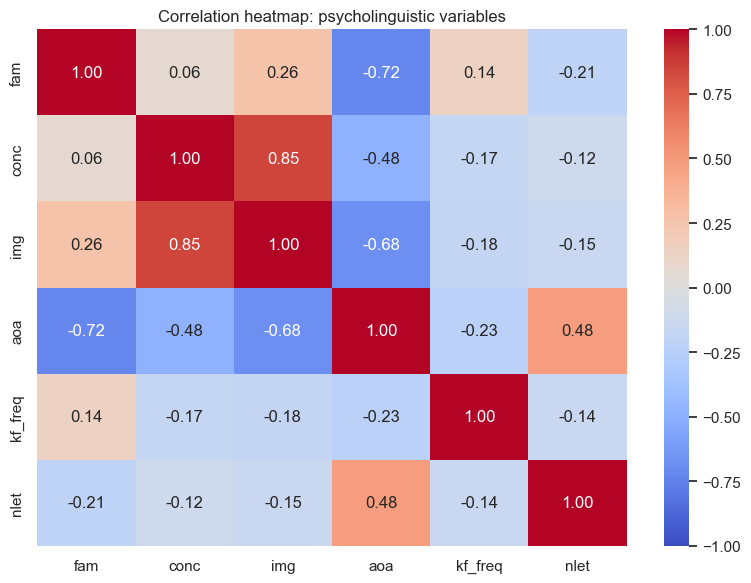

In [ ]:
# Correlation matrix and heatmap between numeric variables
numeric_cols = [c for c in ["fam", "conc", "img", "aoa", "kf_freq", "nlet"] if c in mrc_df.columns]
corr = mrc_df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation heatmap: psycholinguistic variables")
plt.tight_layout()

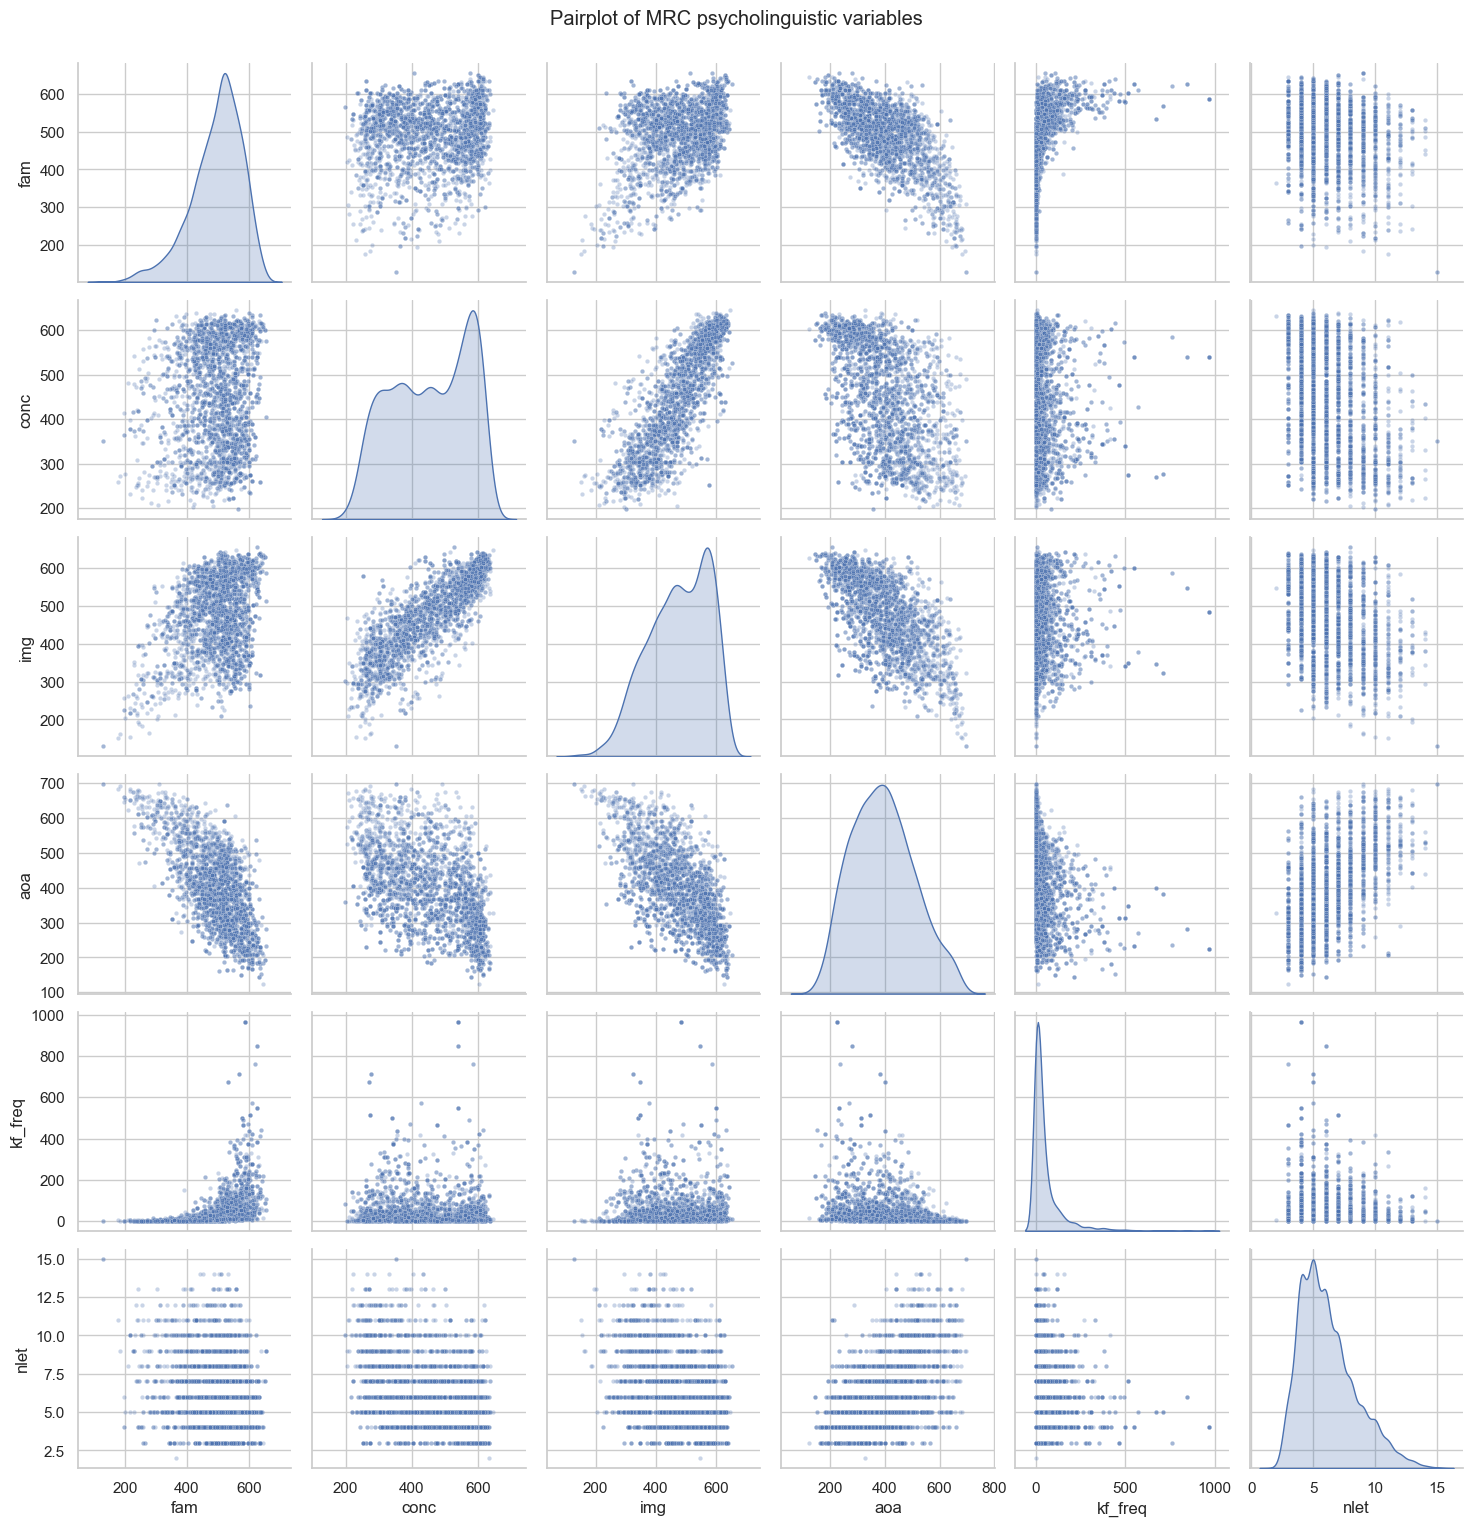

In [ ]:
# Pairwise relationships: scatter plots with KDE on the diagonal
sns.pairplot(mrc_df[numeric_cols].dropna(), kind="scatter", diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pairplot of MRC psycholinguistic variables", y=1.02)
plt.show()

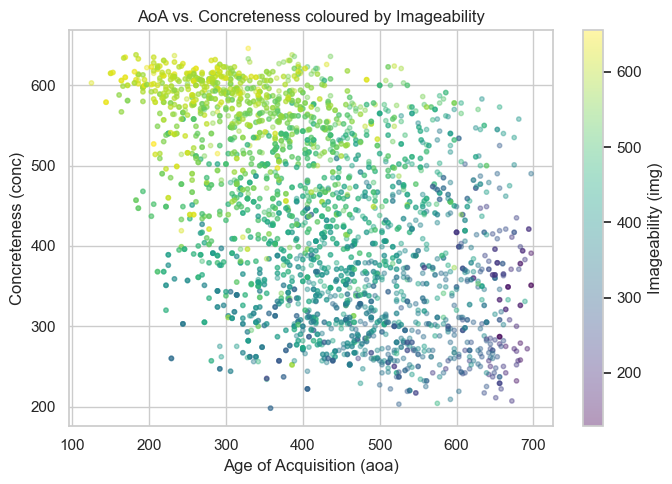

In [ ]:
# Example: AoA vs. concreteness, coloured by imageability
if {"aoa", "conc", "img"}.issubset(mrc_df.columns):
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        mrc_df["aoa"],
        mrc_df["conc"],
        c=mrc_df["img"],
        cmap="viridis",
        alpha=0.4,
        s=10,
    )
    plt.colorbar(sc, label="Imageability (img)")
    plt.xlabel("Age of Acquisition (aoa)")
    plt.ylabel("Concreteness (conc)")
    plt.title("AoA vs. Concreteness coloured by Imageability")
    plt.tight_layout()

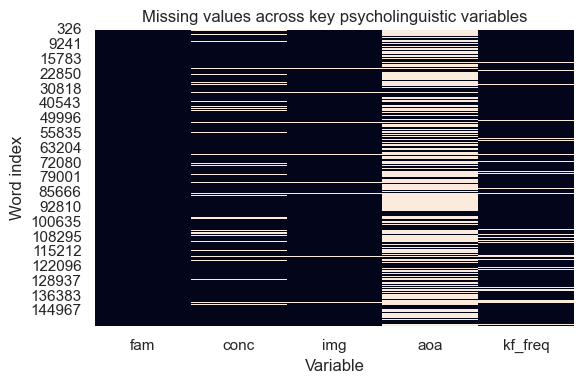

In [ ]:
# Missingness heatmap for key variables
plt.figure(figsize=(6, 4))
sns.heatmap(mrc_df[vars_of_interest].isna(), cbar=False)
plt.title("Missing values across key psycholinguistic variables")
plt.xlabel("Variable")
plt.ylabel("Word index")
plt.tight_layout()